# GINO Evolution + Field Shared-Latent Analysis

Loads the .pt checkpoint produced by GINO_evolution_MLP_sr.ipynb and evaluates both decoders:

- GNO decoder: particle-state queries --> 10-channel delta update.
- MLP decoder: fdom grid queries --> 3-channel velocity field.

Default evaluation uses the MLP decoder on stored grid-query coordinates from the processed .npz. Dense super-resolution slice queries are available as a separate visualization helper.


In [1]:
from __future__ import annotations

import inspect
import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

try:
    from neuralop.layers.gno_block import GNOBlock
except Exception as error:
    GNOBlock = None
    GNO_IMPORT_ERROR = error

try:
    from neuralop.models import FNO
except Exception as error:
    FNO = None
    FNO_IMPORT_ERROR = error

SEED = int(os.environ.get("EVOLUTION_ANALYSIS_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RUN_TAG = "gino_evolution_mlp_sr"
RESULTS_SUBDIR = "result/task1_gino_evolution_mlp_sr"
ANALYSIS_SUBDIR = "analysis_plots"


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "GINO_evolution").is_dir():
        return cwd
    if cwd.name == "GINO_evolution":
        return cwd.parent
    return cwd

REPO_ROOT = repo_root()
RESULTS_DIR = REPO_ROOT / RESULTS_SUBDIR
PLOT_DIR = RESULTS_DIR / ANALYSIS_SUBDIR
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = Path(os.environ.get("EVOLUTION_SR_CKPT", RESULTS_DIR / f"{RUN_TAG}_best_model.pt")).expanduser()
if not CKPT_PATH.is_absolute():
    CKPT_PATH = (Path.cwd() / CKPT_PATH).resolve()
HISTORY_PATH = RESULTS_DIR / f"{RUN_TAG}_history.json"

print("Device:", DEVICE)
print("Checkpoint:", CKPT_PATH)
print("Plot dir:", PLOT_DIR)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Device: cuda
Checkpoint: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/result/task1_gino_evolution_mlp_sr/gino_evolution_mlp_sr_best_model.pt
Plot dir: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/result/task1_gino_evolution_mlp_sr/analysis_plots
GPU: NVIDIA GeForce RTX 5070 Ti


In [2]:
def load_checkpoint(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}. Run GINO_evolution/GINO_evolution_MLP_sr.ipynb first.")
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

checkpoint = load_checkpoint(CKPT_PATH)
CFG = dict(checkpoint.get("config", {}))

# Requires updation everytime training model changes
CFG.setdefault("latent_res", 8)
CFG.setdefault("hidden_channels", 96)
CFG.setdefault("fno_layers", 4)
CFG.setdefault("fno_modes", 6)
CFG.setdefault("gno_radius", 0.12)
CFG.setdefault("mlp_layers", 3)
CFG.setdefault("mlp_hidden", 128)
CFG.setdefault("query_pos_encoding_frequencies", 4)
CFG.setdefault("maximum_input_particles", 4096)
CFG.setdefault("maximum_eval_query_points", 12000)
CFG.setdefault("sr_grid_resolution", 96)

DATASET_PATH = Path(os.environ.get("EVOLUTION_DATASET", checkpoint.get("dataset_path", ""))).expanduser()
if str(DATASET_PATH) in {"", "."}:
    candidates = [
        REPO_ROOT / "processed_data" / "particle_evolution_dataset.npz",
        REPO_ROOT / "process_data_evolution" / "particle_evolution_dataset.npz",
    ]
    DATASET_PATH = next((candidate for candidate in candidates if candidate.exists()), candidates[0])
if not DATASET_PATH.is_absolute():
    DATASET_PATH = (Path.cwd() / DATASET_PATH).resolve()
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")

dataset_file = np.load(DATASET_PATH, allow_pickle=True)
feature_names_all = [str(x) for x in dataset_file["feature_names"].tolist()]
target_names = [str(x) for x in dataset_file["target_names"].tolist()]
field_target_names = [str(x) for x in dataset_file["field_target_names"].tolist()] if "field_target_names" in dataset_file.files else ["u_x", "u_y", "u_z"]
feature_names = [str(x) for x in checkpoint["feature_names"]]
active_input_feature_indices = [feature_names_all.index(name) for name in feature_names]
coord_feature_indices = [feature_names_all.index(name) for name in ("x", "y", "z")]

required_keys = ["query_coords", "targets_velocity_field", "targets_velocity_field_norm", "field_query_mask"]
missing_keys = [key for key in required_keys if key not in dataset_file.files]
if missing_keys:
    raise KeyError(f"Dataset lacks grid-field arrays {missing_keys}. Regenerate with updated processdata_evolution_u.py")

inputs_t = np.asarray(dataset_file["inputs_t"], dtype=np.float32)
inputs_t_norm = np.asarray(dataset_file["inputs_t_norm"], dtype=np.float32)
targets_delta = np.asarray(dataset_file["targets_delta"], dtype=np.float32)
targets_delta_norm = np.asarray(dataset_file["targets_delta_norm"], dtype=np.float32)
query_coords_all = np.asarray(dataset_file["query_coords"], dtype=np.float32)
targets_field = np.asarray(dataset_file["targets_velocity_field"], dtype=np.float32)
targets_field_norm = np.asarray(dataset_file["targets_velocity_field_norm"], dtype=np.float32)
field_query_mask = np.asarray(dataset_file["field_query_mask"], dtype=bool)
frame_ranges = list(dataset_file["pair_ranges"])
frame_contexts = list(dataset_file["pair_contexts"])

inputs_by_pair = []
inputs_by_pair_norm = []
targets_delta_by_pair = []
targets_delta_by_pair_norm = []
for pair_range in frame_ranges:
    start, end = int(pair_range[3]), int(pair_range[4])
    inputs_by_pair.append(inputs_t[start:end])
    inputs_by_pair_norm.append(inputs_t_norm[start:end])
    targets_delta_by_pair.append(targets_delta[start:end])
    targets_delta_by_pair_norm.append(targets_delta_norm[start:end])

train_pair_ids = np.asarray(dataset_file["train_pair_ids"], dtype=np.int64)
val_pair_ids = np.asarray(dataset_file["val_pair_ids"], dtype=np.int64) if "val_pair_ids" in dataset_file.files else np.asarray([], dtype=np.int64)
test_pair_ids = np.asarray(dataset_file["test_pair_ids"], dtype=np.int64) if "test_pair_ids" in dataset_file.files else np.asarray([], dtype=np.int64)

input_mean = np.asarray(checkpoint.get("input_mean", np.asarray(dataset_file["in_mean"]).reshape(-1)[active_input_feature_indices]), dtype=np.float32)
input_std = np.maximum(np.asarray(checkpoint.get("input_std", np.asarray(dataset_file["in_std"]).reshape(-1)[active_input_feature_indices]), dtype=np.float32), 1e-8)
target_mean = np.asarray(checkpoint.get("target_mean", np.asarray(dataset_file["out_mean"]).reshape(-1)), dtype=np.float32)
target_std = np.maximum(np.asarray(checkpoint.get("target_std", np.asarray(dataset_file["out_std"]).reshape(-1)), dtype=np.float32), 1e-8)
field_mean = np.asarray(checkpoint.get("field_mean", np.asarray(dataset_file["field_mean"]).reshape(-1)), dtype=np.float32)
field_std = np.maximum(np.asarray(checkpoint.get("field_std", np.asarray(dataset_file["field_std"]).reshape(-1)), dtype=np.float32), 1e-8)
coord_min = np.asarray(checkpoint.get("coord_min", dataset_file["coord_min"]), dtype=np.float32).reshape(3)
coord_span = np.maximum(np.asarray(checkpoint.get("coord_span", dataset_file["coord_span"]), dtype=np.float32).reshape(3), 1e-8)

print("Dataset:", DATASET_PATH)
print("Features:", feature_names)
print("Delta targets:", target_names)
print("Field targets:", field_target_names)
print("Splits:", {"train": len(train_pair_ids), "val": len(val_pair_ids), "test": len(test_pair_ids)})


Dataset: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/processed_data/particle_evolution_dataset.npz
Features: ['u_x', 'u_y', 'u_z', 'sigma', 'geom_dist']
Delta targets: ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma', 'delta_u_x', 'delta_u_y', 'delta_u_z']
Field targets: ['u_x', 'u_y', 'u_z']
Splits: {'train': 550, 'val': 200, 'test': 100}


In [3]:
def as_context(obj) -> Dict:
    if isinstance(obj, dict):
        return obj
    if hasattr(obj, "item"):
        item = obj.item()
        if isinstance(item, dict):
            return item
    return dict(obj)


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    return np.clip((xyz.astype(np.float32) - coord_min[None, :]) / coord_span[None, :], 0.0, 1.0).astype(np.float32)


def sample_indices(n: int, cap: Optional[int], seed: int) -> np.ndarray:
    if cap is None or cap <= 0 or n <= int(cap):
        return np.arange(n, dtype=np.int64)
    rng = np.random.default_rng(int(seed))
    return np.sort(rng.choice(n, size=int(cap), replace=False)).astype(np.int64)


def collect_rows(pair_ids, arrays_by_pair, max_pairs=12, max_points=5000, seed_offset=0):
    chunks = []
    for pair_id in sample_indices(len(pair_ids), max_pairs, SEED + seed_offset):
        actual_pair_id = int(pair_ids[pair_id])
        arr = np.asarray(arrays_by_pair[actual_pair_id])
        idx = sample_indices(arr.shape[0], max_points, SEED + seed_offset + actual_pair_id)
        chunks.append(arr[idx])
    return np.concatenate(chunks, axis=0) if chunks else np.empty((0, 0), dtype=np.float32)


def collect_field_rows(pair_ids, normalized=False, max_pairs=12, max_points=5000, seed_offset=0):
    source = targets_field_norm if normalized else targets_field
    chunks = []
    for pos in sample_indices(len(pair_ids), max_pairs, SEED + seed_offset):
        pair_id = int(pair_ids[pos])
        valid = np.flatnonzero(field_query_mask[pair_id])
        idx = valid[sample_indices(len(valid), max_points, SEED + seed_offset + pair_id)]
        chunks.append(source[pair_id, idx])
    return np.concatenate(chunks, axis=0) if chunks else np.empty((0, 3), dtype=np.float32)


def denorm_delta_np(y):
    return y * target_std.reshape(1, -1) + target_mean.reshape(1, -1)


def denorm_field_np(y):
    return y * field_std.reshape(1, -1) + field_mean.reshape(1, -1)


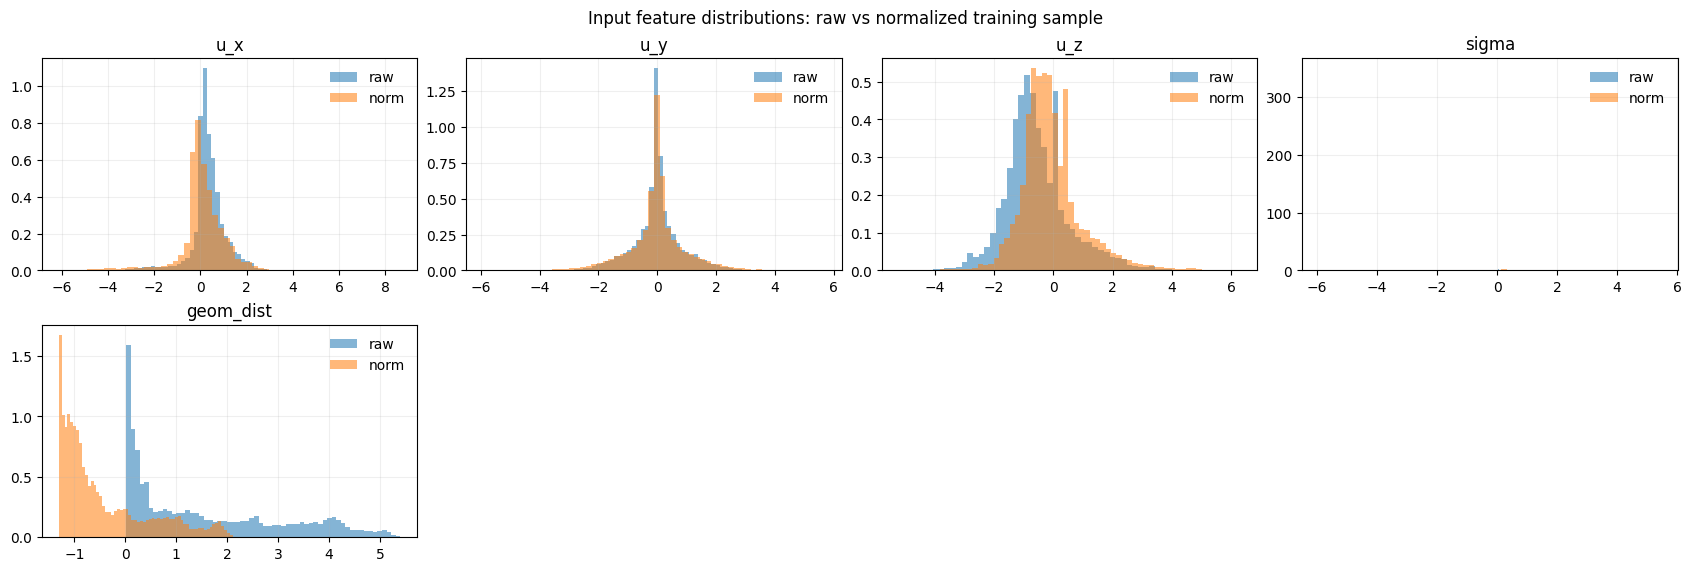

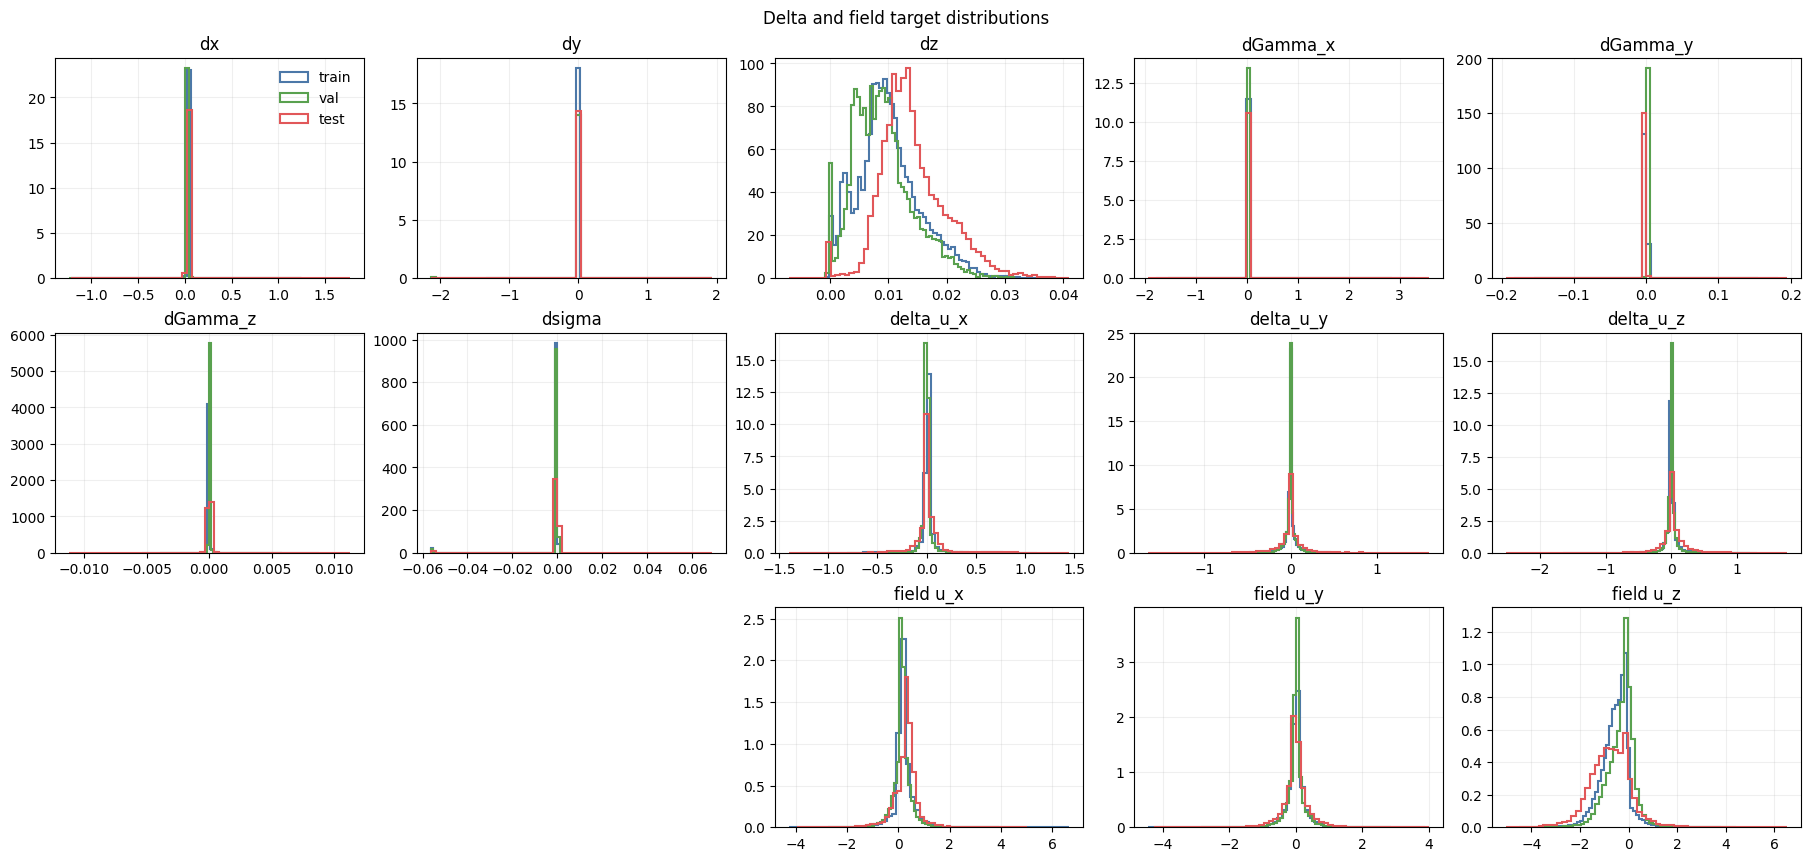

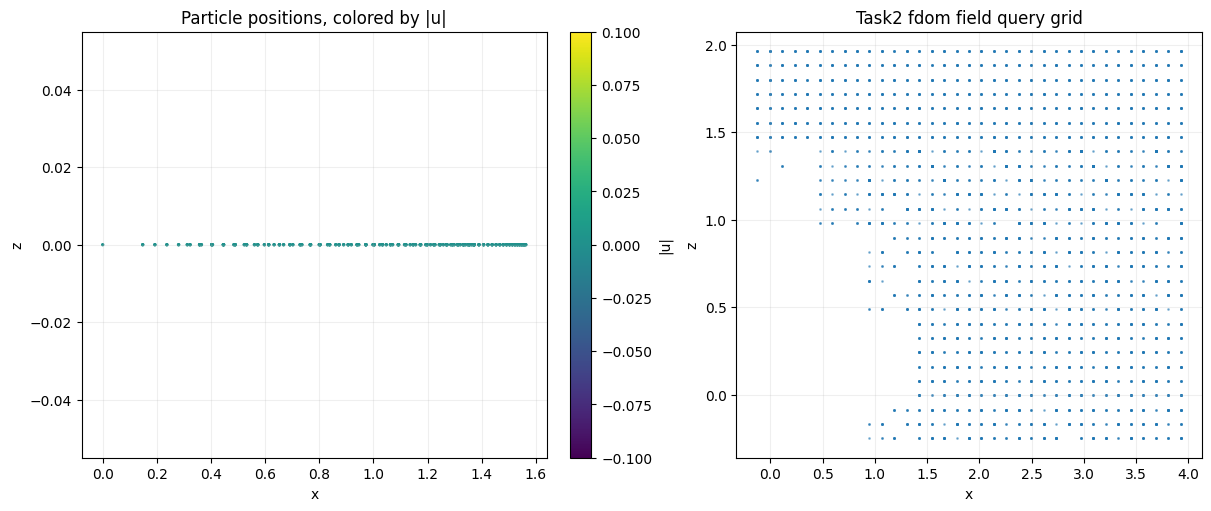

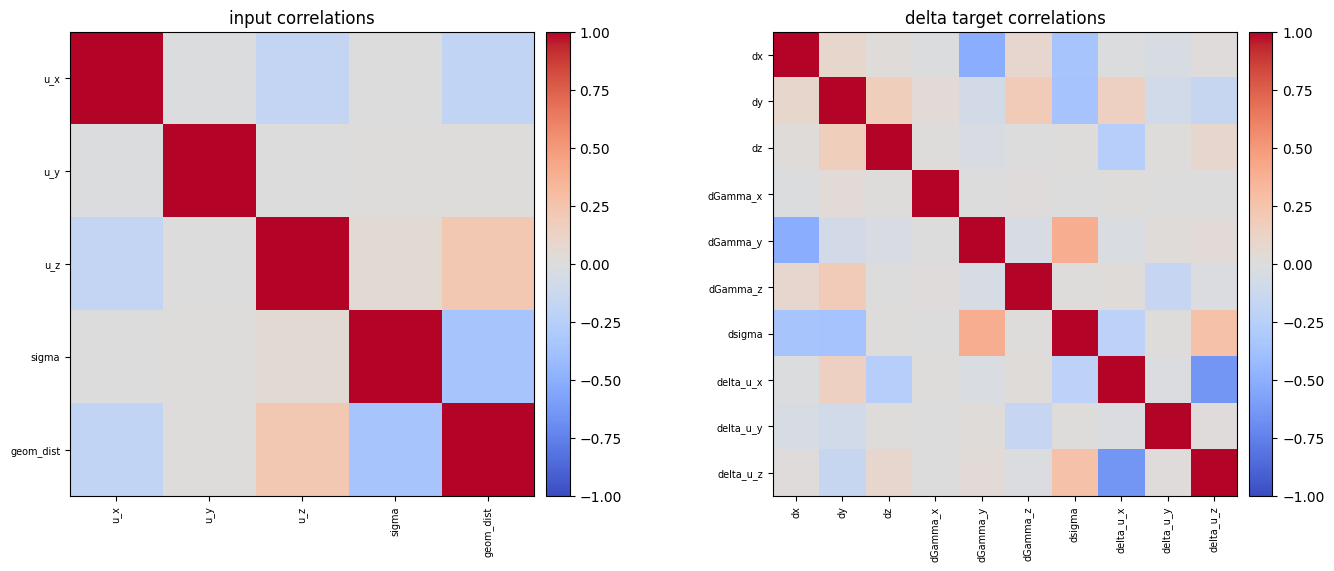

In [4]:
# 1. Data distribution diagnostics.
splits = {"train": train_pair_ids, "val": val_pair_ids, "test": test_pair_ids}
colors = {"train": "#4c78a8", "val": "#59a14f", "test": "#e15759"}

# 1.1 Raw vs normalized input feature histograms for checkpoint channels.
train_raw = collect_rows(train_pair_ids, inputs_by_pair, max_pairs=10, max_points=3000, seed_offset=10)
train_norm_all = collect_rows(train_pair_ids, inputs_by_pair_norm, max_pairs=10, max_points=3000, seed_offset=11)
train_norm = train_norm_all[:, active_input_feature_indices]
raw_selected = train_raw[:, active_input_feature_indices]
cols = min(4, len(feature_names))
rows = int(math.ceil(len(feature_names) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 2.8 * rows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
for i, name in enumerate(feature_names):
    axes[i].hist(raw_selected[:, i], bins=60, alpha=0.55, density=True, label="raw")
    axes[i].hist(train_norm[:, i], bins=60, alpha=0.55, density=True, label="norm")
    axes[i].set_title(name)
    axes[i].grid(alpha=0.2)
    axes[i].legend(frameon=False)
for ax in axes[len(feature_names):]:
    ax.axis("off")
fig.suptitle("Input feature distributions: raw vs normalized training sample")
fig.savefig(PLOT_DIR / "input_feature_raw_vs_norm.png", dpi=220, bbox_inches="tight")
plt.show()

# 1.2 Delta and field target histograms split by train/val/test.
fig, axes = plt.subplots(3, 5, figsize=(18, 8.5), constrained_layout=True)
axes = axes.reshape(-1)
for ch, name in enumerate(target_names):
    ax = axes[ch]
    for split_name, ids in splits.items():
        if len(ids) == 0:
            continue
        values = collect_rows(ids, targets_delta_by_pair, max_pairs=8, max_points=3000, seed_offset=30 + ch)[:, ch]
        ax.hist(values, bins=60, density=True, histtype="step", linewidth=1.5, color=colors[split_name], label=split_name)
    ax.set_title(name)
    ax.grid(alpha=0.2)
axes[10].axis("off")
axes[11].axis("off")
for ch, name in enumerate(field_target_names):
    ax = axes[12 + ch]
    for split_name, ids in splits.items():
        if len(ids) == 0:
            continue
        values = collect_field_rows(ids, normalized=False, max_pairs=8, max_points=3000, seed_offset=50 + ch)[:, ch]
        ax.hist(values, bins=60, density=True, histtype="step", linewidth=1.5, color=colors[split_name], label=split_name)
    ax.set_title(f"field {name}")
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False)
fig.suptitle("Delta and field target distributions")
fig.savefig(PLOT_DIR / "target_distributions.png", dpi=220, bbox_inches="tight")
plt.show()

# 1.3 Spatial coverage: particles and field grid.
example_pair = int(test_pair_ids[0] if len(test_pair_ids) else train_pair_ids[0])
particle_raw = inputs_by_pair[example_pair]
valid = np.flatnonzero(field_query_mask[example_pair])
field_xyz = query_coords_all[example_pair, valid]
particle_speed = np.linalg.norm(particle_raw[:, [feature_names_all.index("u_x"), feature_names_all.index("u_y"), feature_names_all.index("u_z")]], axis=1) if all(k in feature_names_all for k in ["u_x", "u_y", "u_z"]) else np.linalg.norm(particle_raw[:, coord_feature_indices], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
idx_p = sample_indices(particle_raw.shape[0], 12000, SEED + 70)
sc = axes[0].scatter(particle_raw[idx_p, coord_feature_indices[0]], particle_raw[idx_p, coord_feature_indices[2]], c=particle_speed[idx_p], s=2, cmap="viridis")
axes[0].set_title("Particle positions, colored by |u|")
axes[0].set_xlabel("x"); axes[0].set_ylabel("z")
plt.colorbar(sc, ax=axes[0], label="|u|")
idx_f = sample_indices(field_xyz.shape[0], 20000, SEED + 71)
axes[1].scatter(field_xyz[idx_f, 0], field_xyz[idx_f, 2], s=1, alpha=0.45)
axes[1].set_title("Task2 fdom field query grid")
axes[1].set_xlabel("x"); axes[1].set_ylabel("z")
for ax in axes: ax.grid(alpha=0.2)
fig.savefig(PLOT_DIR / "spatial_coverage_particles_vs_field.png", dpi=220, bbox_inches="tight")
plt.show()

# 1.4 Correlation matrices.
delta_sample = collect_rows(train_pair_ids, targets_delta_by_pair, max_pairs=10, max_points=3000, seed_offset=80)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), constrained_layout=True)
for ax, data, names, title in [(axes[0], raw_selected, feature_names, "input correlations"), (axes[1], delta_sample, target_names, "delta target correlations")]:
    corr = np.corrcoef(np.nan_to_num(data).T)
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=7); ax.set_yticklabels(names, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
fig.savefig(PLOT_DIR / "correlation_matrices.png", dpi=220, bbox_inches="tight")
plt.show()


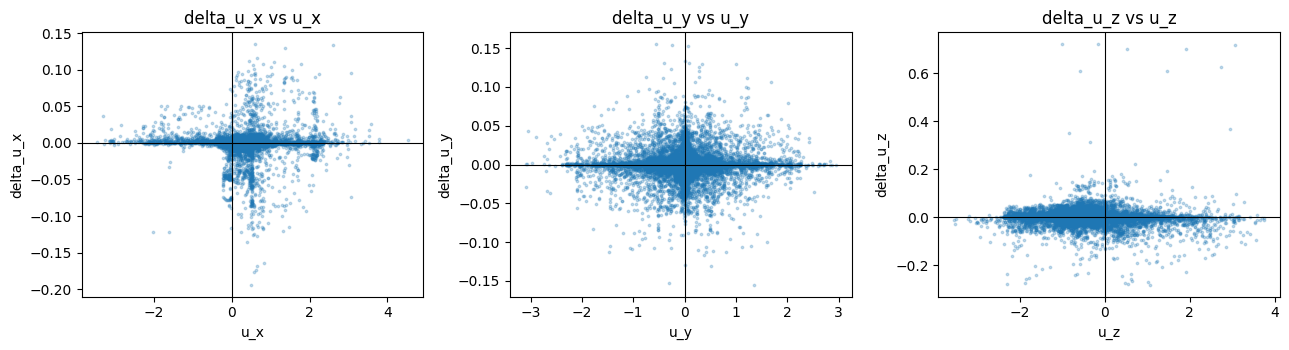

/tmp/ipykernel_569469/32647782.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_labels, showfliers=False)


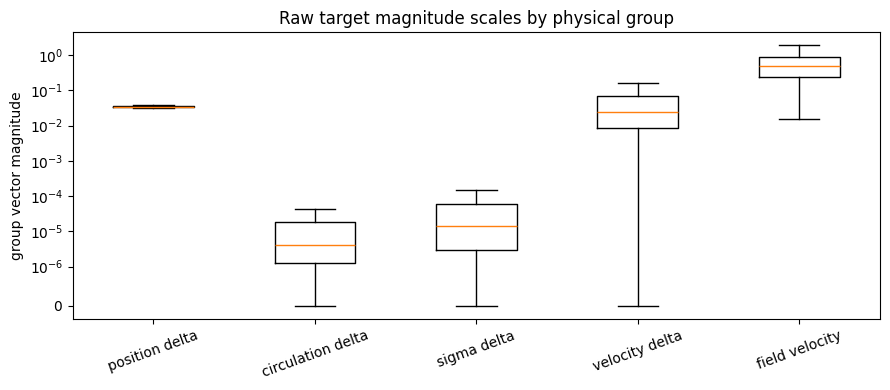

In [5]:

# 1.5 Current velocity vs delta velocity and group-scale box plots.
velocity_names = ["u_x", "u_y", "u_z"]
delta_velocity_names = ["delta_u_x", "delta_u_y", "delta_u_z"]
if all(name in feature_names for name in velocity_names) and all(name in target_names for name in delta_velocity_names):
    u_idx = [feature_names.index(name) for name in velocity_names]
    du_idx = [target_names.index(name) for name in delta_velocity_names]
    vel_rows = raw_selected[:, u_idx]
    du_rows = delta_sample[:, du_idx]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for i, ax in enumerate(axes):
        n = min(len(vel_rows), len(du_rows), 12000)
        pick = sample_indices(n, n, SEED + 400 + i)
        ax.scatter(vel_rows[pick, i], du_rows[pick, i], s=3, alpha=0.25)
        ax.axhline(0.0, color="black", linewidth=0.8)
        ax.axvline(0.0, color="black", linewidth=0.8)
        ax.set_xlabel(velocity_names[i])
        ax.set_ylabel(delta_velocity_names[i])
        ax.set_title(f"{delta_velocity_names[i]} vs {velocity_names[i]}")
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "delta_u_vs_current_u.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("Skipping delta-u/current-u scatter because velocity channels are not present in this dataset/checkpoint.")

group_defs = [
    ("position delta", [i for i, name in enumerate(target_names) if name in ["dx", "dy", "dz"]]),
    ("circulation delta", [i for i, name in enumerate(target_names) if name in ["dGamma_x", "dGamma_y", "dGamma_z"]]),
    ("sigma delta", [i for i, name in enumerate(target_names) if name == "dsigma"]),
    ("velocity delta", [i for i, name in enumerate(target_names) if name in delta_velocity_names]),
    ("field velocity", list(range(len(field_target_names)))),
]
box_data, box_labels = [], []
for label, idx in group_defs:
    if not idx:
        continue
    if label == "field velocity":
        vals = collect_field_rows(train_pair_ids, normalized=False, max_pairs=12, max_points=5000, seed_offset=420)
    else:
        vals = delta_sample[:, idx]
    if vals.size:
        box_data.append(np.linalg.norm(np.atleast_2d(vals), axis=1))
        box_labels.append(label)
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(box_data, labels=box_labels, showfliers=False)
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_ylabel("group vector magnitude")
ax.set_title("Raw target magnitude scales by physical group")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(PLOT_DIR / "target_group_scale_boxplots.png", dpi=220, bbox_inches="tight")
plt.show()


In [6]:
def make_latent_queries(res: int, device: torch.device) -> torch.Tensor:
    line = torch.linspace(0.0, 1.0, int(res), dtype=torch.float32, device=device)
    xx, yy, zz = torch.meshgrid(line, line, line, indexing="ij")
    return torch.stack([xx, yy, zz], dim=-1).reshape(1, -1, 3)

LATENT_QUERIES = make_latent_queries(CFG["latent_res"], DEVICE)


def make_gnoblock(in_channels, out_channels, radius):
    if GNOBlock is None:
        raise RuntimeError("neuralop.layers.gno_block.GNOBlock is not available") from GNO_IMPORT_ERROR
    kwargs = dict(
        in_channels=in_channels,
        out_channels=out_channels,
        coord_dim=3,
        radius=float(radius),
        transform_type="linear",
        reduction="mean",
        pos_embedding_type="transformer",
        pos_embedding_channels=12,
        channel_mlp_layers=[out_channels, out_channels, out_channels],
    )
    accepted = set(inspect.signature(GNOBlock.__init__).parameters)
    if "use_torch_scatter_reduce" in accepted:
        kwargs["use_torch_scatter_reduce"] = False
    if "use_open3d_neighbor_search" in accepted:
        kwargs["use_open3d_neighbor_search"] = False
    return GNOBlock(**{k: v for k, v in kwargs.items() if k in accepted})


def positional_encoding(coords, num_frequencies: int):
    if int(num_frequencies) <= 0:
        return coords
    freqs = (2.0 ** torch.arange(int(num_frequencies), device=coords.device, dtype=coords.dtype)).view(1, 1, -1)
    angles = coords.unsqueeze(-1) * freqs * math.pi
    return torch.cat([coords, torch.sin(angles).flatten(-2), torch.cos(angles).flatten(-2)], dim=-1)


class GINOSharedLatent(nn.Module):
    def __init__(self, in_channels, delta_channels, field_channels, global_channels, cfg):
        super().__init__()
        hidden = int(cfg["hidden_channels"])
        self.latent_res = int(cfg["latent_res"])
        self.query_pe_freqs = int(cfg["query_pos_encoding_frequencies"])
        self.lift = nn.Sequential(nn.Linear(in_channels, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.global_condition_mlp = nn.Sequential(nn.Linear(global_channels, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.encoder = make_gnoblock(hidden, hidden, cfg["gno_radius"])
        if FNO is None:
            raise RuntimeError("neuralop.models.FNO is not available; install/use neuralop with FNO support") from FNO_IMPORT_ERROR
        modes = min(int(cfg["fno_modes"]), max(self.latent_res // 2, 1))
        self.fno = FNO(n_modes=(modes, modes, modes), in_channels=hidden, out_channels=hidden, hidden_channels=hidden, n_layers=int(cfg["fno_layers"]), positional_embedding=None)
        self.delta_decoder_gno = make_gnoblock(hidden, hidden, cfg["delta_gno_radius"])
        self.particle_skip_proj = nn.Linear(hidden, hidden)
        self.delta_fusion = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.delta_head = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, delta_channels))
        query_dim = 3 + 2 * 3 * self.query_pe_freqs
        width = int(cfg["mlp_hidden"])
        layers = []
        for layer_id in range(max(int(cfg["mlp_layers"]), 1)):
            layers += [nn.Linear((hidden + query_dim) if layer_id == 0 else width, width), nn.GELU()]
        layers.append(nn.Linear(width, field_channels))
        self.field_decoder = nn.Sequential(*layers)
        self.log_delta_var = nn.Parameter(torch.zeros(()))
        self.log_field_var = nn.Parameter(torch.zeros(()))

    def apply_gno(self, block, source_coords, query_coords, source_features):
        # Direction is source points -> query points. In this installed neuralop,
        # GNOBlock names source coordinates `y` and query coordinates `x`.
        return block(y=source_coords, x=query_coords, f_y=source_features)

    def encode_process(self, input_geom, latent_queries, x):
        base_latent = latent_queries[0]
        r = self.latent_res
        grids = []
        flat_latents = []
        for b in range(x.shape[0]):
            h = self.lift(x[b])
            latent = self.apply_gno(self.encoder, source_coords=input_geom[b], query_coords=base_latent, source_features=h)
            if latent.ndim == 3:
                latent = latent.squeeze(0)
            grid = latent.reshape(r, r, r, -1).permute(3, 0, 1, 2).unsqueeze(0)
            processed_grid = self.fno(grid)
            processed_flat = processed_grid.squeeze(0).permute(1, 2, 3, 0).reshape(-1, processed_grid.shape[1])
            grids.append(processed_grid)
            flat_latents.append(processed_flat)
        return base_latent, grids, flat_latents

    def sample_grid(self, grid, queries):
        q = queries.clamp(0.0, 1.0)
        sample_grid = (q * 2.0 - 1.0).view(1, -1, 1, 1, 3)
        sampled = torch.nn.functional.grid_sample(grid, sample_grid, align_corners=True, mode="bilinear")
        return sampled.squeeze(0).squeeze(-1).squeeze(-1).transpose(0, 1)

    def forward(self, input_geom, latent_queries, output_queries, x):
        base_latent, grids, flat_latents = self.encode_process(input_geom, latent_queries, x)
        delta_outputs = []
        field_outputs = []
        for b, (grid, flat_latent) in enumerate(zip(grids, flat_latents)):
            particle_latent = self.apply_gno(self.delta_decoder_gno, source_coords=base_latent, query_coords=input_geom[b], source_features=flat_latent)
            if particle_latent.ndim == 3:
                particle_latent = particle_latent.squeeze(0)
            delta_outputs.append(self.delta_head(particle_latent))
            q = output_queries[b].clamp(0.0, 1.0)
            sampled = self.sample_grid(grid, q)
            field_outputs.append(self.field_decoder(torch.cat([sampled, positional_encoding(q.unsqueeze(0), self.query_pe_freqs).squeeze(0)], dim=-1)))
        return torch.stack(delta_outputs, dim=0), torch.stack(field_outputs, dim=0)

checkpoint_cfg = checkpoint["config"]
predict_delta_u = checkpoint_cfg.get("predict_delta_u", True)
delta_channels = 10 if predict_delta_u else 7
global_channels = len(checkpoint_cfg.get("global_condition_channels", []))

# model = GINOSharedLatent(len(feature_names), len(target_names), len(field_target_names), CFG).to(DEVICE)
model = GINOSharedLatent(
    len(checkpoint["feature_names"]),  # input channels used during training
    delta_channels,
    len(checkpoint["field_target_names"]),
    global_channels,
    checkpoint_cfg
).to(DEVICE)
# model.load_state_dict(checkpoint["model_state_dict"], strict=True)

state_dict = checkpoint["model_state_dict"]
state_dict.pop("_metadata", None)          # remove auto‑added metadata if present
model.load_state_dict(state_dict, strict=True)



model.eval()
print("Loaded model parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


Loaded model parameters: 14,761,100


In [7]:
# ----------------------------------------------------------------------
# Helper: global condition vector (copy from training notebook)
# ----------------------------------------------------------------------
# The list of global condition channels must match the checkpoint
GLOBAL_CONDITION_CHANNELS = checkpoint["config"].get(
    "global_condition_channels",
    ["angle_of_attack", "freestream_magnitude", "phase"]
)

def context_global_params(context: Dict, phase: Optional[float] = None) -> np.ndarray:
    freestream = np.asarray(context.get("freestream", [0.0, 0.0, 0.0]), dtype=np.float32).reshape(-1)
    if freestream.size < 3:
        freestream = np.pad(freestream, (0, 3 - freestream.size))
    values = {
        "angle_of_attack": float(context.get("aoa_deg", 0.0)) / 45.0,
        "freestream_magnitude": float(np.linalg.norm(freestream)) / 10.0,
        "freestream_x": float(freestream[0]) / 10.0,
        "freestream_y": float(freestream[1]) / 10.0,
        "freestream_z": float(freestream[2]) / 10.0,
        "phase": float(context.get("phase_t", 0.0) if phase is None else phase),
    }
    return np.asarray([values[name] for name in GLOBAL_CONDITION_CHANNELS], dtype=np.float32)

# ----------------------------------------------------------------------
# Feature & target setup from the checkpoint (not from the notebook defaults)
# ----------------------------------------------------------------------
feature_names = checkpoint["feature_names"]              # list of input channel names used during training
active_input_feature_indices = [feature_names_all.index(name) for name in feature_names]
target_names = checkpoint["target_names"]                # already sliced to delta_channels
delta_channels = len(target_names)

# The normalisation statistics for delta are already sliced in the checkpoint
target_mean = checkpoint["target_mean"]
target_std = checkpoint["target_std"]

# ----------------------------------------------------------------------
# Corrected dataset class
# ----------------------------------------------------------------------
class EvolutionAnalysisDataset(Dataset):
    def __init__(self, pair_ids, max_input_particles=None, max_query_points=None):
        self.pair_ids = np.asarray(pair_ids, dtype=np.int64)
        self.max_input_particles = max_input_particles
        self.max_query_points = max_query_points

    def __len__(self):
        return int(len(self.pair_ids))

    def __getitem__(self, index):
        pair_id = int(self.pair_ids[int(index)])
        features_all = np.asarray(inputs_by_pair[pair_id], dtype=np.float32)
        delta_norm_all = np.asarray(targets_delta_by_pair_norm[pair_id], dtype=np.float32)
        n = min(features_all.shape[0], delta_norm_all.shape[0])
        input_idx = sample_indices(n, self.max_input_particles, SEED + pair_id)
        input_features = features_all[input_idx]

        # Normalise input features using the checkpoint statistics
        x = (input_features[:, active_input_feature_indices] - input_mean[None, :]) / input_std[None, :]

        # Slice delta targets to the correct number of channels (7 or 10)
        y_delta = delta_norm_all[input_idx, :delta_channels]

        # Field queries
        valid = np.flatnonzero(field_query_mask[pair_id])
        query_idx = valid[sample_indices(len(valid), self.max_query_points, SEED + 100000 + pair_id)]
        query_xyz = query_coords_all[pair_id, query_idx]
        y_field = targets_field_norm[pair_id, query_idx]

        # Global conditioning vector
        context = as_context(frame_contexts[pair_id])
        global_params = context_global_params(context)

        return {
            "input_geom": torch.from_numpy(normalize_xyz(input_features[:, coord_feature_indices])).unsqueeze(0),
            "x": torch.from_numpy(np.clip(np.nan_to_num(x), -8.0, 8.0).astype(np.float32)).unsqueeze(0),
            "output_queries": torch.from_numpy(normalize_xyz(query_xyz)).unsqueeze(0),
            "query_xyz_raw": torch.from_numpy(query_xyz.astype(np.float32)).unsqueeze(0),
            "y_delta": torch.from_numpy(np.nan_to_num(y_delta).astype(np.float32)).unsqueeze(0),
            "y_field": torch.from_numpy(np.nan_to_num(y_field).astype(np.float32)).unsqueeze(0),
            "input_features_raw": torch.from_numpy(input_features.astype(np.float32)).unsqueeze(0),
            "pair_id": torch.tensor([pair_id], dtype=torch.long),
            "global_params": torch.from_numpy(global_params).unsqueeze(0),
        }

# ----------------------------------------------------------------------
# Updated move_batch, denormalize, and predict (no changes needed)
# ----------------------------------------------------------------------
def move_batch(batch):
    return {key: (value.to(DEVICE, non_blocking=True) if torch.is_tensor(value) else value)
            for key, value in batch.items()}

def denormalize_delta_t(y):
    target_mean_t = torch.tensor(target_mean, dtype=torch.float32, device=y.device).view(1, 1, -1)
    target_std_t = torch.tensor(target_std, dtype=torch.float32, device=y.device).view(1, 1, -1)
    return y * target_std_t + target_mean_t

def denormalize_field_t(y):
    field_mean_t = torch.tensor(field_mean, dtype=torch.float32, device=y.device).view(1, 1, -1)
    field_std_t = torch.tensor(field_std, dtype=torch.float32, device=y.device).view(1, 1, -1)
    return y * field_std_t + field_mean_t

def relative_l2_t(pred, target, eps=1e-12):
    return torch.linalg.norm((pred - target).reshape(pred.shape[0], -1), dim=1) / \
           torch.linalg.norm(target.reshape(target.shape[0], -1), dim=1).clamp_min(eps)

@torch.no_grad()
def predict_batch(batch):
    return model(batch["input_geom"], LATENT_QUERIES, batch["output_queries"],
                 batch["x"], batch["global_params"])

# Instantiate the test dataset
test_ds = EvolutionAnalysisDataset(
    test_pair_ids if len(test_pair_ids) else val_pair_ids if len(val_pair_ids) else train_pair_ids,
    CFG.get("maximum_input_particles"),
    CFG.get("maximum_eval_query_points")
)
print("Analysis dataset pairs:", len(test_ds))

Analysis dataset pairs: 100


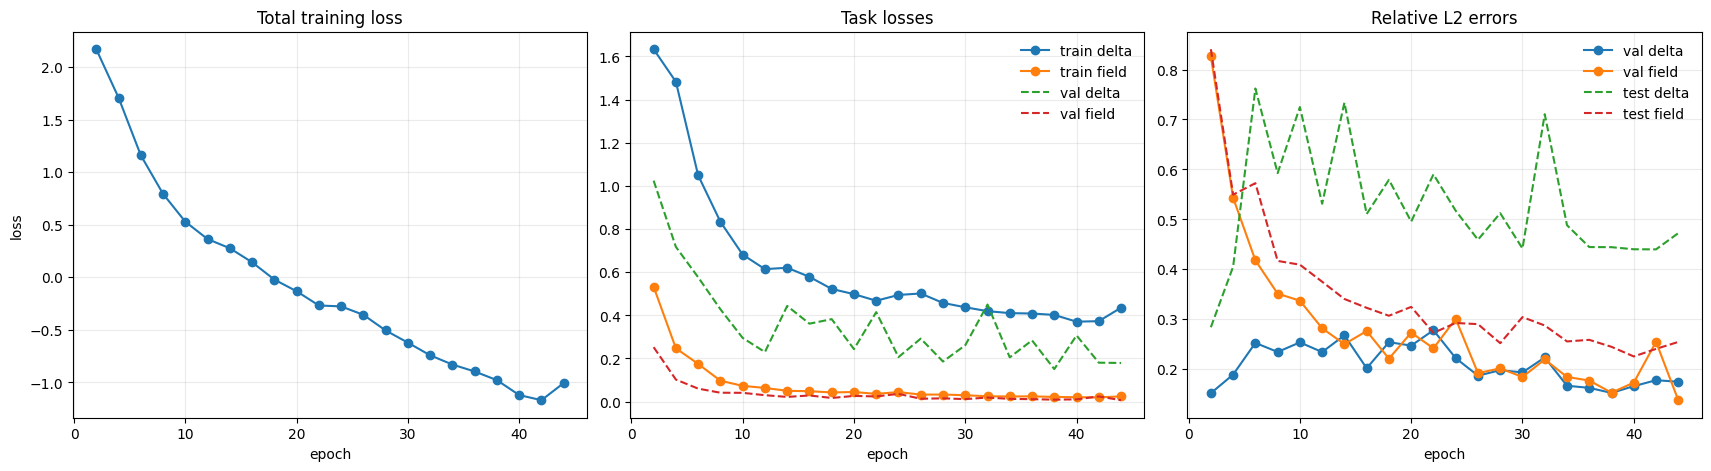

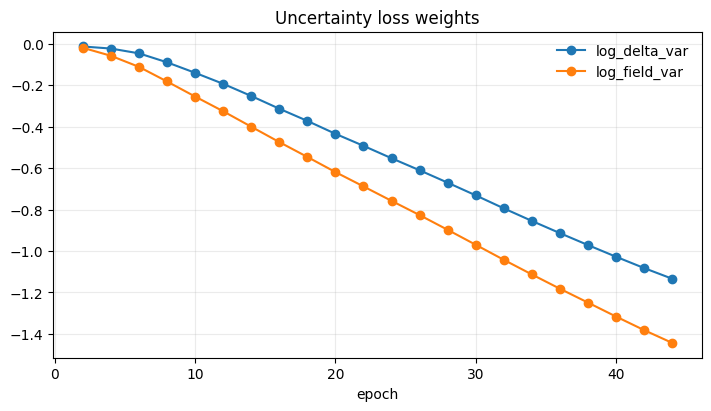

In [8]:
# 2. Training history plots.
history = checkpoint.get("history", [])
if not history and HISTORY_PATH.exists():
    history = json.loads(HISTORY_PATH.read_text())
if not history:
    print("No history available in checkpoint or history JSON.")
else:
    epochs = np.asarray([row["epoch"] for row in history])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o")
    axes[0].set_title("Total training loss")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.25)
    axes[1].plot(epochs, [row.get("train_delta_loss", np.nan) for row in history], marker="o", label="train delta")
    axes[1].plot(epochs, [row.get("train_field_loss", np.nan) for row in history], marker="o", label="train field")
    axes[1].plot(epochs, [row.get("val", {}).get("delta_loss", np.nan) for row in history], "--", label="val delta")
    axes[1].plot(epochs, [row.get("val", {}).get("field_loss", np.nan) for row in history], "--", label="val field")
    axes[1].set_title("Task losses")
    axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.25); axes[1].legend(frameon=False)
    axes[2].plot(epochs, [row.get("val", {}).get("delta_rel_l2", np.nan) for row in history], marker="o", label="val delta")
    axes[2].plot(epochs, [row.get("val", {}).get("field_rel_l2", np.nan) for row in history], marker="o", label="val field")
    axes[2].plot(epochs, [row.get("test", {}).get("delta_rel_l2", np.nan) for row in history], "--", label="test delta")
    axes[2].plot(epochs, [row.get("test", {}).get("field_rel_l2", np.nan) for row in history], "--", label="test field")
    axes[2].set_title("Relative L2 errors")
    axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(PLOT_DIR / "training_history_losses_errors.png", dpi=220, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.plot(epochs, [row.get("log_delta_var", np.nan) for row in history], marker="o", label="log_delta_var")
    ax.plot(epochs, [row.get("log_field_var", np.nan) for row in history], marker="o", label="log_field_var")
    ax.set_title("Uncertainty loss weights")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.25); ax.legend(frameon=False)
    fig.savefig(PLOT_DIR / "uncertainty_weights.png", dpi=220, bbox_inches="tight")
    plt.show()


In [9]:
# 3. Quantitative test-set performance.
@torch.no_grad()
def collect_predictions(dataset, max_samples=12):
    rows = []
    delta_abs_by_channel = []
    field_abs_by_channel = []
    for local_idx in sample_indices(len(dataset), max_samples, SEED + 200):
        batch, delta_pred, field_pred = predict_batch(dataset[int(local_idx)])
        delta_pred_phys = denormalize_delta_t(delta_pred).cpu().numpy()[0]
        delta_true_phys = denormalize_delta_t(batch["y_delta"]).cpu().numpy()[0]
        field_pred_phys = denormalize_field_t(field_pred).cpu().numpy()[0]
        field_true_phys = denormalize_field_t(batch["y_field"]).cpu().numpy()[0]
        delta_rel = float(relative_l2_t(torch.from_numpy(delta_pred_phys).unsqueeze(0), torch.from_numpy(delta_true_phys).unsqueeze(0)).mean())
        field_rel = float(relative_l2_t(torch.from_numpy(field_pred_phys).unsqueeze(0), torch.from_numpy(field_true_phys).unsqueeze(0)).mean())
        rows.append({"pair_id": int(batch["pair_id"].item()), "delta_rel_l2": delta_rel, "field_rel_l2": field_rel})
        delta_abs_by_channel.append(np.mean(np.abs(delta_pred_phys - delta_true_phys), axis=0))
        field_abs_by_channel.append(np.mean(np.abs(field_pred_phys - field_true_phys), axis=0))
    return rows, np.asarray(delta_abs_by_channel), np.asarray(field_abs_by_channel)

metric_rows, delta_channel_errors, field_channel_errors = collect_predictions(test_ds, max_samples=min(20, len(test_ds)))
print(json.dumps({
    "delta_rel_l2_mean": float(np.mean([r["delta_rel_l2"] for r in metric_rows])),
    "delta_rel_l2_median": float(np.median([r["delta_rel_l2"] for r in metric_rows])),
    "field_rel_l2_mean": float(np.mean([r["field_rel_l2"] for r in metric_rows])),
    "field_rel_l2_median": float(np.median([r["field_rel_l2"] for r in metric_rows])),
    "samples": len(metric_rows),
}, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), constrained_layout=True)
axes[0].boxplot([delta_channel_errors[:, i] for i in range(delta_channel_errors.shape[1])], labels=target_names, vert=True, showfliers=False)
axes[0].set_title("Delta decoder mean absolute error by channel")
axes[0].tick_params(axis="x", rotation=90); axes[0].grid(axis="y", alpha=0.25)
axes[1].boxplot([field_channel_errors[:, i] for i in range(field_channel_errors.shape[1])], labels=field_target_names, vert=True, showfliers=False)
axes[1].set_title("MLP field decoder mean absolute error by channel")
axes[1].grid(axis="y", alpha=0.25)
fig.savefig(PLOT_DIR / "test_channel_error_boxplots.png", dpi=220, bbox_inches="tight")
plt.show()

# Predicted-vs-true scatter for dx and field u_x on one sample.
batch, delta_pred, field_pred = predict_batch(test_ds[0])
delta_pred_phys = denormalize_delta_t(delta_pred).cpu().numpy()[0]
delta_true_phys = denormalize_delta_t(batch["y_delta"]).cpu().numpy()[0]
field_pred_phys = denormalize_field_t(field_pred).cpu().numpy()[0]
field_true_phys = denormalize_field_t(batch["y_field"]).cpu().numpy()[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for ax, truth, pred, label in [(axes[0], delta_true_phys[:, 0], delta_pred_phys[:, 0], "dx"), (axes[1], field_true_phys[:, 0], field_pred_phys[:, 0], "field u_x")]:
    idx = sample_indices(len(truth), 20000, SEED + 300)
    truth_s, pred_s = truth[idx], pred[idx]
    lo = float(np.quantile(np.concatenate([truth_s, pred_s]), 0.01)); hi = float(np.quantile(np.concatenate([truth_s, pred_s]), 0.99))
    r2 = float(np.corrcoef(truth_s, pred_s)[0, 1] ** 2) if len(truth_s) > 1 else np.nan
    ax.scatter(truth_s, pred_s, s=3, alpha=0.25)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"{label}: pred vs true, R2={r2:.3f}")
    ax.set_xlabel("true"); ax.set_ylabel("predicted"); ax.grid(alpha=0.25)
fig.savefig(PLOT_DIR / "pred_vs_true_scatter.png", dpi=220, bbox_inches="tight")
plt.show()


TypeError: GINOSharedLatent.forward() takes 5 positional arguments but 6 were given

In [ ]:
# 4. Qualitative decoder visualizations.
# 4.1 Particle update accuracy in x-z projection.
input_raw = batch["input_features_raw"].cpu().numpy()[0]
x_idx, y_idx, z_idx = coord_feature_indices
true_next = input_raw[:, coord_feature_indices] + delta_true_phys[:, 0:3]
pred_next = input_raw[:, coord_feature_indices] + delta_pred_phys[:, 0:3]
err = np.linalg.norm(pred_next - true_next, axis=1)
idx = sample_indices(input_raw.shape[0], 12000, SEED + 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
axes[0].scatter(input_raw[idx, x_idx], input_raw[idx, z_idx], s=2, alpha=0.35, label="t")
axes[0].scatter(true_next[idx, 0], true_next[idx, 2], s=2, alpha=0.35, label="true t+1")
axes[0].scatter(pred_next[idx, 0], pred_next[idx, 2], s=2, alpha=0.35, label="pred t+1")
axes[0].set_title("Particle cloud evolution")
axes[0].legend(frameon=False)
qidx = idx[::max(len(idx)//250, 1)]
axes[1].quiver(true_next[qidx, 0], true_next[qidx, 2], pred_next[qidx, 0] - true_next[qidx, 0], pred_next[qidx, 2] - true_next[qidx, 2], err[qidx], angles="xy", scale_units="xy", scale=1.0, width=0.003)
axes[1].set_title("Predicted position error vectors")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("z"); ax.grid(alpha=0.2)
fig.savefig(PLOT_DIR / "particle_update_accuracy.png", dpi=220, bbox_inches="tight")
plt.show()

# 4.2 MLP field decoder on stored fdom queries.
query_xyz = batch["query_xyz_raw"].cpu().numpy()[0]
field_error = np.linalg.norm(field_pred_phys - field_true_phys, axis=1)
true_mag = np.linalg.norm(field_true_phys, axis=1)
pred_mag = np.linalg.norm(field_pred_phys, axis=1)
idx = sample_indices(query_xyz.shape[0], 25000, SEED + 401)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
vmn, vmx = np.quantile(np.concatenate([true_mag[idx], pred_mag[idx]]), [0.02, 0.98])
items = [(true_mag, "true |u|", "viridis", vmn, vmx), (pred_mag, "pred |u|", "viridis", vmn, vmx), (field_error, "|u_pred-u_true|", "magma", None, None)]
for ax, (values, title, cmap, lo, hi) in zip(axes, items):
    sc = ax.scatter(query_xyz[idx, 0], query_xyz[idx, 2], c=values[idx], s=2, cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("z"); ax.grid(alpha=0.2)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
fig.savefig(PLOT_DIR / "field_decoder_stored_grid_queries.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
ax.hist(field_error, bins=100, density=True, alpha=0.85)
ax.set_title("Per-point field velocity error magnitude")
ax.set_xlabel("|u_pred - u_true|"); ax.set_ylabel("density"); ax.grid(alpha=0.25)
fig.savefig(PLOT_DIR / "field_error_histogram.png", dpi=220, bbox_inches="tight")
plt.show()


In [ ]:

# 4.3 Stored-query energy spectrum diagnostic for the MLP field decoder.
def radial_power_spectrum_from_scatter(xz, values, bins: int = 96):
    x = xz[:, 0]
    z = xz[:, 1]
    mag = np.asarray(values, dtype=np.float64)
    if len(mag) < 16:
        return np.array([]), np.array([])
    xi = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), bins)
    zi = np.linspace(float(np.nanmin(z)), float(np.nanmax(z)), bins)
    try:
        from scipy.interpolate import griddata
        grid = griddata(np.column_stack([x, z]), mag, (xi[None, :], zi[:, None]), method="linear")
        nearest = griddata(np.column_stack([x, z]), mag, (xi[None, :], zi[:, None]), method="nearest")
        grid = np.where(np.isfinite(grid), grid, nearest)
    except Exception:
        grid = np.full((bins, bins), np.nan, dtype=np.float64)
        ix = np.clip(np.searchsorted(xi, x) - 1, 0, bins - 1)
        iz = np.clip(np.searchsorted(zi, z) - 1, 0, bins - 1)
        counts = np.zeros_like(grid)
        for a, b, v in zip(iz, ix, mag):
            grid[a, b] = np.nan_to_num(grid[a, b]) + v
            counts[a, b] += 1
        grid = np.divide(grid, np.maximum(counts, 1.0), out=np.zeros_like(grid), where=counts > 0)
    grid = np.nan_to_num(grid - np.nanmean(grid), nan=0.0)
    power = np.abs(np.fft.fftshift(np.fft.fft2(grid))) ** 2
    yy, xx = np.indices(power.shape)
    rr = np.sqrt((xx - bins / 2) ** 2 + (yy - bins / 2) ** 2).astype(int)
    max_r = max(1, bins // 2)
    spectrum = np.bincount(rr.ravel(), weights=power.ravel(), minlength=max_r + 1)[:max_r]
    counts = np.bincount(rr.ravel(), minlength=max_r + 1)[:max_r]
    spectrum = spectrum / np.maximum(counts, 1)
    return np.arange(max_r), spectrum

field_xz = batch["query_xyz_raw"].cpu().numpy()[0][:, [0, 2]]
k_true, spec_true = radial_power_spectrum_from_scatter(field_xz, true_mag)
k_pred, spec_pred = radial_power_spectrum_from_scatter(field_xz, pred_mag)
if len(k_true) and len(k_pred):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.loglog(k_true[1:], spec_true[1:] + 1e-30, label="true |u|")
    ax.loglog(k_pred[1:], spec_pred[1:] + 1e-30, label="pred |u|")
    ax.set_xlabel("radial wavenumber")
    ax.set_ylabel("power")
    ax.set_title("MLP field decoder energy spectrum on stored fdom queries")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "field_energy_spectrum_stored_queries.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("Skipping energy spectrum: not enough field query points in the selected sample.")


In [ ]:
# 4.3 Optional dense MLP decoder query. This uses the same MLP decoder, not a separate SR model.
USE_DENSE_SR_DEMO = bool(int(os.environ.get("EVOLUTION_ANALYSIS_DENSE_SR", "1")))

@torch.no_grad()
def predict_u_on_field_grid(pair_id: int, grid_resolution: int = 96, y_value: Optional[float] = None):
    features_all = np.asarray(inputs_by_pair[int(pair_id)], dtype=np.float32)
    input_idx = sample_indices(features_all.shape[0], CFG.get("maximum_input_particles"), SEED + int(pair_id))
    input_features = features_all[input_idx]
    x = (input_features[:, active_input_feature_indices] - input_mean[None, :]) / input_std[None, :]
    x_line = np.linspace(coord_min[0], coord_min[0] + coord_span[0], grid_resolution, dtype=np.float32)
    z_line = np.linspace(coord_min[2], coord_min[2] + coord_span[2], grid_resolution, dtype=np.float32)
    xx, zz = np.meshgrid(x_line, z_line, indexing="xy")
    if y_value is None:
        y_value = float(np.median(features_all[:, coord_feature_indices[1]]))
    yy = np.full_like(xx, y_value, dtype=np.float32)
    query_xyz = np.stack([xx, yy, zz], axis=-1).reshape(-1, 3)
    dense_batch = {
        "input_geom": torch.from_numpy(normalize_xyz(input_features[:, coord_feature_indices])).unsqueeze(0).to(DEVICE),
        "x": torch.from_numpy(np.clip(np.nan_to_num(x), -8.0, 8.0).astype(np.float32)).unsqueeze(0).to(DEVICE),
        "output_queries": torch.from_numpy(normalize_xyz(query_xyz)).unsqueeze(0).to(DEVICE),
    }
    _, field_pred = model(dense_batch["input_geom"], LATENT_QUERIES, dense_batch["output_queries"], dense_batch["x"])
    u = denormalize_field_t(field_pred).squeeze(0).cpu().numpy()
    return query_xyz, u, u.reshape(grid_resolution, grid_resolution, 3)

if USE_DENSE_SR_DEMO:
    pair_id = int(batch["pair_id"].item())
    query_xyz_dense, u_flat_dense, u_grid_dense = predict_u_on_field_grid(pair_id, grid_resolution=int(CFG.get("sr_grid_resolution", 96)))
    u_mag_dense = np.linalg.norm(u_grid_dense, axis=-1)
    fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
    im = ax.imshow(u_mag_dense, origin="lower", extent=[query_xyz_dense[:,0].min(), query_xyz_dense[:,0].max(), query_xyz_dense[:,2].min(), query_xyz_dense[:,2].max()], aspect="auto")
    ax.set_title("Dense MLP decoder query |u|")
    ax.set_xlabel("x"); ax.set_ylabel("z")
    plt.colorbar(im, ax=ax, label="|u|")
    fig.savefig(PLOT_DIR / "dense_mlp_decoder_query.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("Dense SR demo skipped by default. Set EVOLUTION_ANALYSIS_DENSE_SR=1 to run it.")


In [ ]:
# 5. Inference speed and resource usage.
@torch.no_grad()
def time_forward(dataset, query_caps=(1024, 4096, 12000), repetitions=30):
    if len(dataset) == 0:
        return []
    results = []
    pair_id = int(dataset.pair_ids[0])
    for cap in query_caps:
        timed_ds = EvolutionAnalysisDataset([pair_id], CFG.get("maximum_input_particles"), cap)
        timed_batch = move_batch(timed_ds[0])
        for _ in range(5):
            _ = model(timed_batch["input_geom"], LATENT_QUERIES, timed_batch["output_queries"], timed_batch["x"])
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
        times = []
        for _ in range(int(repetitions)):
            t0 = time.perf_counter()
            _ = model(timed_batch["input_geom"], LATENT_QUERIES, timed_batch["output_queries"], timed_batch["x"])
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
        peak_mb = torch.cuda.max_memory_allocated() / 1024**2 if DEVICE.type == "cuda" else np.nan
        results.append({"query_points": int(timed_batch["output_queries"].shape[1]), "mean_ms": float(np.mean(times) * 1000), "std_ms": float(np.std(times) * 1000), "peak_cuda_mb": float(peak_mb)})
    return results

timing = time_forward(test_ds, repetitions=int(os.environ.get("EVOLUTION_ANALYSIS_TIMING_REPS", "20")))
print(json.dumps(timing, indent=2))
if timing:
    fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
    ax.errorbar([r["query_points"] for r in timing], [r["mean_ms"] for r in timing], yerr=[r["std_ms"] for r in timing], marker="o")
    ax.set_xlabel("field query points")
    ax.set_ylabel("forward time ms")
    ax.set_title(f"Inference scaling on {DEVICE}")
    ax.grid(alpha=0.25)
    fig.savefig(PLOT_DIR / "inference_time_vs_query_points.png", dpi=220, bbox_inches="tight")
    plt.show()
